***Section 1.0***

Load Data and Libraries

In [ ]:
#load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from datasets import Dataset, DatasetDict
from openai import OpenAI
from transformers import AutoTokenizer
from transformers import TrainingArguments
from sklearn.metrics import f1_score
from transformers import Trainer

In [ ]:
data_df = pd.read_csv("complaints-2026-03-02_19_07.csv")

In [ ]:
import os
os.path.getsize("complaints-2026-03-02_19_07.csv") #check size to make sure it loaded correctly in case issues with loading large dataset

442791910

***Section 2.0***

Exploratory Data Analysis and Preprocessing

In [ ]:
data_df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,10/03/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,The Fair Credit Reporting Act ( 15 U.S. Code 1...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CT,06516,NaN,Consent provided,Web,10/03/25,Closed with explanation,Yes,NaN,16316337
1,12/22/25,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A Macy 's credit card was opened under my name...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,752XX,NaN,Consent provided,Web,12/22/25,Closed with explanation,Yes,NaN,18219388
2,11/10/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am formally disputing inaccurate information...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NY,10466,NaN,Consent provided,Web,11/10/25,Closed with non-monetary relief,Yes,NaN,17120972
3,12/22/25,Student loan,Private student loan,Issue where my lender is my school,Issues with fees connected to the loan,My spouse and I attended XXXX XXXX XXXX from X...,NaN,"Maximus Federal Services, Inc.",TX,75243,NaN,Consent provided,Web,12/22/25,Closed with explanation,Yes,NaN,18232083
4,10/26/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,Be sure that disputed accounts are taken down ...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,93619,NaN,Consent provided,Web,10/26/25,Closed with non-monetary relief,Yes,NaN,16826857


In [ ]:
data_df.shape

(310808, 18)

In [ ]:
data_df.columns #check column names

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')

In [ ]:
#clean up column names
data_df.columns = data_df.columns.str.strip().str.lower().str.replace(" ", "_")
data_df.columns

Index(['date_received', 'product', 'sub-product', 'issue', 'sub-issue',
       'consumer_complaint_narrative', 'company_public_response', 'company',
       'state', 'zip_code', 'tags', 'consumer_consent_provided?',
       'submitted_via', 'date_sent_to_company', 'company_response_to_consumer',
       'timely_response?', 'consumer_disputed?', 'complaint_id'],
      dtype='object')

In [ ]:
#check for missing data
data_df['consumer_complaint_narrative'].isna().sum()

np.int64(0)

In [ ]:
data_df.info() #confirm cloumn name clean up

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310808 entries, 0 to 310807
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   date_received                 310808 non-null  object 
 1   product                       310808 non-null  object 
 2   sub-product                   310808 non-null  object 
 3   issue                         310808 non-null  object 
 4   sub-issue                     298417 non-null  object 
 5   consumer_complaint_narrative  310808 non-null  object 
 6   company_public_response       168265 non-null  object 
 7   company                       310808 non-null  object 
 8   state                         309969 non-null  object 
 9   zip_code                      310808 non-null  object 
 10  tags                          18549 non-null   object 
 11  consumer_consent_provided?    310808 non-null  object 
 12  submitted_via                 310808 non-nul

In [ ]:
#Complaint narrative appears to need some cleaning
data_df['consumer_complaint_narrative'] = data_df['consumer_complaint_narrative'].str.replace("\r", " ", regex=False)
data_df['consumer_complaint_narrative'] = data_df['consumer_complaint_narrative'].str.replace("\n", " ", regex=False) #new line character
data_df['consumer_complaint_narrative'] = data_df['consumer_complaint_narrative'].str.strip() #extra whitespace

In [ ]:
#check target label
data_df["product"].value_counts()

,count
product,
Credit reporting or other personal consumer reports,221930
Debt collection,33613
Credit card,15719
Checking or savings account,15276
"Money transfer, virtual currency, or money service",7634
Mortgage,5108
Vehicle loan or lease,4276
"Payday loan, title loan, personal loan, or advance loan",2848
Student loan,2353


In [ ]:
top_products = data_df["product"].value_counts().head(4).index #get top products for modeling
data_df = data_df[data_df["product"].isin(top_products)].copy() #filter dataset so we only have data with top 4 largest products and save over original dataframe

In [ ]:
#check new df
data_df["product"].value_counts()

,count
product,
Credit reporting or other personal consumer reports,221930
Debt collection,33613
Credit card,15719
Checking or savings account,15276


In [ ]:
#shorten product names for visualizations. create new column with name mapping
product_map = {
    "Checking or savings account": "Checking/Savings",
    "Credit card": "Credit Card",
    "Credit reporting or other personal consumer reports": "Credit Reporting",
    "Debt collection": "Debt Collection"
}

data_df["product_short"] = data_df["product"].map(product_map)

In [ ]:
data_df["product_short"].value_counts()

,count
product_short,
Credit Reporting,221930
Debt Collection,33613
Credit Card,15719
Checking/Savings,15276


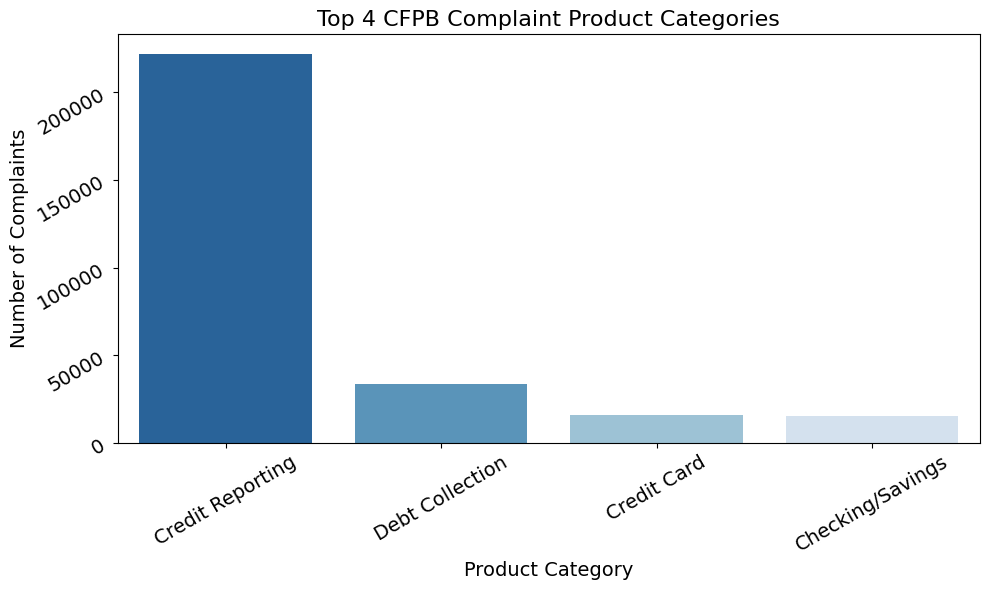

In [ ]:
#histogram to visualize dataset imbalance
top_counts = data_df["product_short"].value_counts().head(4)

plot_df = top_counts.reset_index()
plot_df.columns = ["product", "count"]

plt.figure(figsize=(10,6))

sns.barplot(
    data=plot_df,
    x="product",
    y="count",
    hue="product",
    palette="Blues_r",
    legend=False
)

plt.title("Top 4 CFPB Complaint Product Categories", fontsize=16)
plt.xlabel("Product Category", fontsize=14)
plt.ylabel("Number of Complaints", fontsize=14)
plt.xticks(rotation=30, fontsize=14)
plt.yticks(rotation=30, fontsize=14)
plt.tight_layout()

plt.show()

In [ ]:
#downsample to the minimum
min_count = data_df["product_short"].value_counts().min()

df_balanced = (
     data_df.groupby("product_short", group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .reset_index(drop=True)
)

df_balanced["product_short"].value_counts()

/tmp/ipykernel_10715/1945905146.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_count, random_state=42))


,count
product_short,
Checking/Savings,15276
Credit Card,15276
Credit Reporting,15276
Debt Collection,15276


In [ ]:
#need to clean up the narrative text field
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'\bx+\b', ' ', text)  #xxxx a redaction (a privacy placeholder) in the dataset
    text = re.sub(r'[^a-z\s]', ' ', text)   # keep letters + spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_balanced["clean_text"] = df_balanced["consumer_complaint_narrative"].apply(basic_clean)

In [ ]:
df_balanced["tokens"] = df_balanced["clean_text"].str.split()

In [ ]:
all_tokens = [token for tokens in df_balanced["tokens"] for token in tokens]

word_counts = Counter(all_tokens)
word_counts.most_common(20)

[('the', 477742),
 ('i', 357953),
 ('and', 345697),
 ('to', 341778),
 ('my', 237465),
 ('a', 232501),
 ('of', 220245),
 ('that', 152865),
 ('this', 136858),
 ('account', 120749),
 ('was', 116134),
 ('credit', 113961),
 ('on', 110599),
 ('not', 109558),
 ('in', 102896),
 ('is', 102692),
 ('for', 92914),
 ('they', 83605),
 ('with', 80057),
 ('or', 79798)]

In [ ]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

filtered_tokens = [w for w in all_tokens if w not in stop_words and len(w) > 2]

word_counts_filtered = Counter(filtered_tokens)
word_counts_filtered.most_common(30)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('account', 120749),
 ('credit', 113961),
 ('information', 52189),
 ('reporting', 51650),
 ('report', 48141),
 ('bank', 39771),
 ('debt', 38815),
 ('card', 38212),
 ('accounts', 35579),
 ('consumer', 31940),
 ('payment', 31823),
 ('dispute', 30705),
 ('year', 29765),
 ('fcra', 25846),
 ('balance', 23830),
 ('provide', 23452),
 ('act', 22775),
 ('never', 22425),
 ('request', 22221),
 ('collection', 21880),
 ('inaccurate', 21684),
 ('without', 21401),
 ('received', 21360),
 ('would', 20980),
 ('fair', 20931),
 ('reported', 20621),
 ('complaint', 19482),
 ('number', 18702),
 ('time', 18565),
 ('days', 18244)]

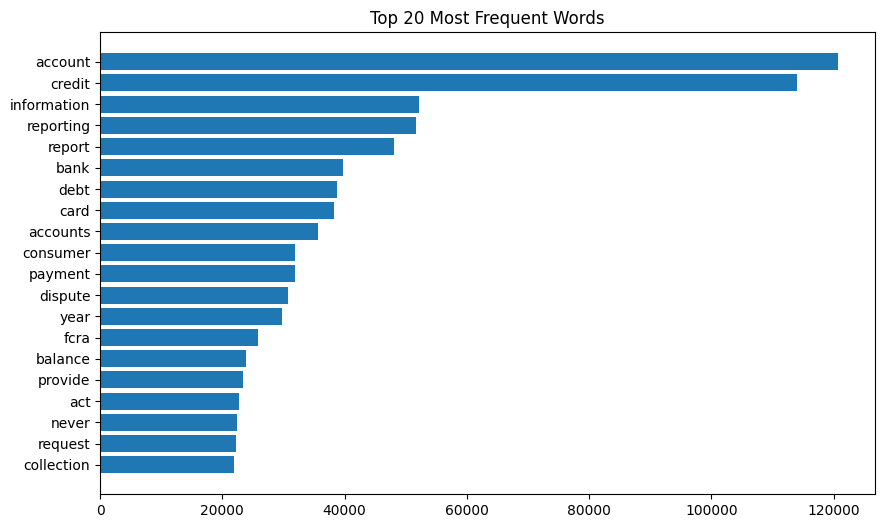

In [ ]:
#visualization of most frequent words in narrative field
top_words = word_counts_filtered.most_common(20)
words_df = pd.DataFrame(top_words, columns=["word", "count"])

plt.figure(figsize=(10,6))
plt.barh(words_df["word"], words_df["count"])
plt.gca().invert_yaxis()
plt.title("Top 20 Most Frequent Words")
plt.show()

In [ ]:
#word count per product category
for product in df_balanced["product_short"].unique():
    product_tokens = [
        token
        for tokens in df_balanced[df_balanced["product_short"] == product]["tokens"]
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]
    print("\n", product)
    print(Counter(product_tokens).most_common(10))


 Checking/Savings
[('account', 46989), ('bank', 25778), ('funds', 14633), ('money', 12034), ('year', 11817), ('check', 9915), ('card', 9884), ('told', 9549), ('would', 9186), ('fraud', 7897)]

 Credit Card
[('credit', 33603), ('account', 27327), ('card', 25716), ('payment', 16543), ('bank', 11961), ('year', 10812), ('dispute', 10397), ('information', 10219), ('one', 8600), ('would', 8578)]

 Credit Reporting
[('credit', 42774), ('reporting', 25749), ('report', 23206), ('information', 22397), ('account', 21003), ('accounts', 18605), ('consumer', 16769), ('fcra', 15829), ('inaccurate', 12237), ('act', 9898)]

 Debt Collection
[('debt', 32451), ('credit', 30112), ('account', 25430), ('reporting', 18298), ('collection', 17502), ('report', 16255), ('information', 12829), ('validation', 9905), ('provide', 8181), ('request', 8078)]


In [ ]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=30
)

X_bigrams = vectorizer.fit_transform(df_balanced["clean_text"])
bigrams = vectorizer.get_feature_names_out()

print(bigrams)

['account number' 'act fcra' 'alleged debt' 'bank america'
 'checking account' 'collection practices' 'consumer report'
 'consumer reporting' 'credit bureaus' 'credit card' 'credit file'
 'credit report' 'credit reporting' 'credit reports' 'customer service'
 'date opened' 'debit card' 'debt collection' 'fair credit' 'fair debt'
 'identity theft' 'inaccurate information' 'late payment'
 'original creditor' 'practices act' 'reporting act' 'reporting agencies'
 'reporting agency' 'reporting credit' 'wells fargo']


***Section 3.0***

Modeling

Model 1: Baseline (Rules Based)

In [ ]:
#make keywords for model 1
keyword_rules = {
    "Checking/Savings": [
        "bank", "account", "funds", "check", "deposit", "withdraw"
    ],

    "Credit Card": [
        "credit card", "card", "balance", "payment", "limit", "charge"
    ],

    "Credit Reporting": [
        "credit report", "reporting", "fcra", "inaccurate", "credit bureau"
    ],

    "Debt Collection": [
        "debt", "collection", "collector", "validation", "owe"
    ]
}

In [ ]:
#make function
def rule_based_classifier(text):

    scores = {product: 0 for product in keyword_rules} #counter

    for product, keywords in keyword_rules.items(): #loop through each category
        for word in keywords: #loop through keywords
            if word in text: #add to list
                scores[product] += 1

    return max(scores, key=scores.get)

In [ ]:
#apply function
df_balanced["baseline_prediction"] = df_balanced["clean_text"].apply(rule_based_classifier)

In [ ]:
#define true labels and predicted labels
y_true_BL = df_balanced["product_short"]
y_pred_BL = df_balanced["baseline_prediction"]
#print
print("Accuracy:", accuracy_score(y_true_BL, y_pred_BL))

print("\nClassification Report:\n")
print(classification_report(y_true_BL, y_pred_BL))

Accuracy: 0.6390416339355852

Classification Report:

                  precision    recall  f1-score   support

Checking/Savings       0.58      0.90      0.70     15276
     Credit Card       0.70      0.58      0.64     15276
Credit Reporting       0.58      0.71      0.64     15276
 Debt Collection       0.93      0.36      0.51     15276

        accuracy                           0.64     61104
       macro avg       0.70      0.64      0.62     61104
    weighted avg       0.70      0.64      0.62     61104



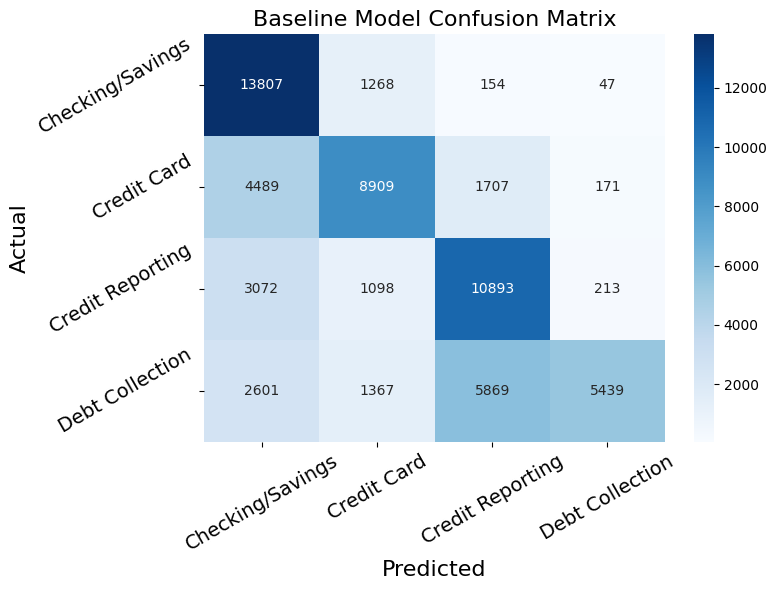

In [ ]:
#confusion matrix analysis
cm_BL = confusion_matrix(y_true_BL, y_pred_BL)

plt.figure(figsize=(8,6))
sns.heatmap(cm_BL, annot=True, fmt="d",
            xticklabels=df_balanced["product_short"].unique(),
            yticklabels=df_balanced["product_short"].unique(),
            cmap="Blues")

plt.xlabel("Predicted", fontsize=16)
plt.ylabel("Actual", fontsize=16)
plt.title("Baseline Model Confusion Matrix", fontsize=16)
plt.xticks(rotation=30, fontsize=14)
plt.yticks(rotation=30, fontsize=14)
plt.tight_layout()
plt.show()

Model 2: Traditional Machine Learning (TF-IDF, Linear SVM)

In [ ]:
X = df_balanced["clean_text"] #input text
y = df_balanced["product_short"] #target labels
#split data 80/20%
X_train, X_test, y_train, y_test_svm = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#convert text into numerical features using TF-IDF
tfidf = TfidfVectorizer(
    stop_words="english", #remove common words
    max_features=5000,    #limit words
    ngram_range=(1,2)   #look at unigrams and bigrams
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train) #train model
y_pred_svm = svm_model.predict(X_test_tfidf) #predict

In [ ]:
print("Accuracy:", accuracy_score(y_test_svm, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test_svm, y_pred_svm))

Accuracy: 0.8925619834710744

Classification Report:

                  precision    recall  f1-score   support

Checking/Savings       0.91      0.92      0.92      3055
     Credit Card       0.88      0.85      0.86      3055
Credit Reporting       0.90      0.91      0.91      3056
 Debt Collection       0.88      0.88      0.88      3055

        accuracy                           0.89     12221
       macro avg       0.89      0.89      0.89     12221
    weighted avg       0.89      0.89      0.89     12221



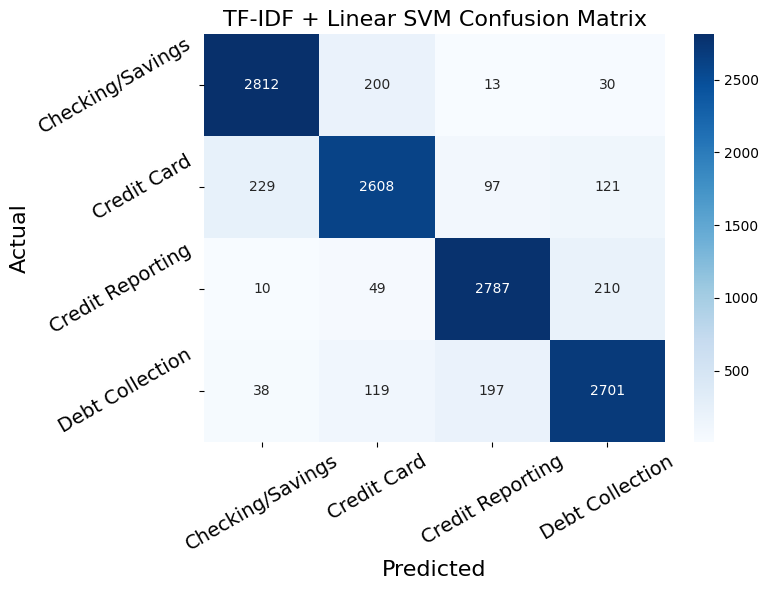

In [ ]:
cm_svm = confusion_matrix(y_test_svm, y_pred_svm)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)
plt.xlabel("Predicted", fontsize=16)
plt.ylabel("Actual", fontsize=16)
plt.title("TF-IDF + Linear SVM Confusion Matrix", fontsize=16)
plt.xticks(rotation=30, fontsize=14)
plt.yticks(rotation=30, fontsize=14)
plt.tight_layout()
plt.show()

Model 3: Transformer Based Model (BERT fine-tuning)

In [ ]:
#model 3 built with code from homework and help from AI
!pip install -q transformers datasets evaluate accelerate
label_list = sorted(df_balanced["product_short"].unique()) #convert category names into numeric IDs
label2id = {label: i for i, label in enumerate(label_list)} #maps label to number for Bert
id2label = {i: label for label, i in label2id.items()}    #maps number to back to label

df_bert = df_balanced[["clean_text", "product_short"]].copy()
df_bert["label"] = df_bert["product_short"].map(label2id)

df_bert.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00


,clean_text,product_short,label
0,a little over a year ago i took a small cash a...,Checking/Savings,0
1,b summary ni am filing this complaint again be...,Checking/Savings,0
2,weaponization of the dispute process reference...,Checking/Savings,0
3,claim im victim of fraud by a merchant taking ...,Checking/Savings,0
4,i opened my checking account year i was never ...,Checking/Savings,0


In [ ]:
#Split 80/20
train_df, test_df = train_test_split(
    df_bert,
    test_size=0.2,
    random_state=42,
    stratify=df_bert["label"]
)

print(train_df.shape, test_df.shape)

(48883, 3) (12221, 3)


In [ ]:
#creates hugging face dataset for BERT
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df[["clean_text", "label"]], preserve_index=False),
    "test": Dataset.from_pandas(test_df[["clean_text", "label"]], preserve_index=False)
})

dataset

DatasetDict({
    train: Dataset({
        features: ['clean_text', 'label'],
        num_rows: 48883
    })
    test: Dataset({
        features: ['clean_text', 'label'],
        num_rows: 12221
    })
})

In [ ]:
#used distilBert
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/48883 [00:00<?, ? examples/s]

Map:   0%|          | 0/12221 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import evaluate
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")

    return {
        "accuracy": accuracy["accuracy"],
        "macro_f1": f1["f1"]
    }

In [ ]:
#takes about 5-8 minutes to run
training_args = TrainingArguments(
    output_dir="bert_cfpb_results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,         #3 took a long time even with GPU
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)
#train model
trainer.train()

eval_results = trainer.evaluate()
print(eval_results)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.329650,0.305535,0.897963,0.897877
2,0.194355,0.299420,0.905245,0.905153


{'eval_loss': 0.2994195222854614, 'eval_accuracy': 0.9052450699615416, 'eval_macro_f1': 0.9051531783239799, 'eval_runtime': 26.8843, 'eval_samples_per_second': 454.578, 'eval_steps_per_second': 28.418, 'epoch': 2.0}


In [ ]:
#predictions
pred_output = trainer.predict(tokenized_dataset["test"])
y_pred_bert = np.argmax(pred_output.predictions, axis=1)
y_true_bert = np.array(test_df["label"])

print(classification_report(
    y_true_bert,
    y_pred_bert,
    target_names=label_list
))

                  precision    recall  f1-score   support

Checking/Savings       0.92      0.93      0.93      3055
     Credit Card       0.89      0.87      0.88      3055
Credit Reporting       0.91      0.93      0.92      3056
 Debt Collection       0.90      0.89      0.90      3055

        accuracy                           0.91     12221
       macro avg       0.91      0.91      0.91     12221
    weighted avg       0.91      0.91      0.91     12221



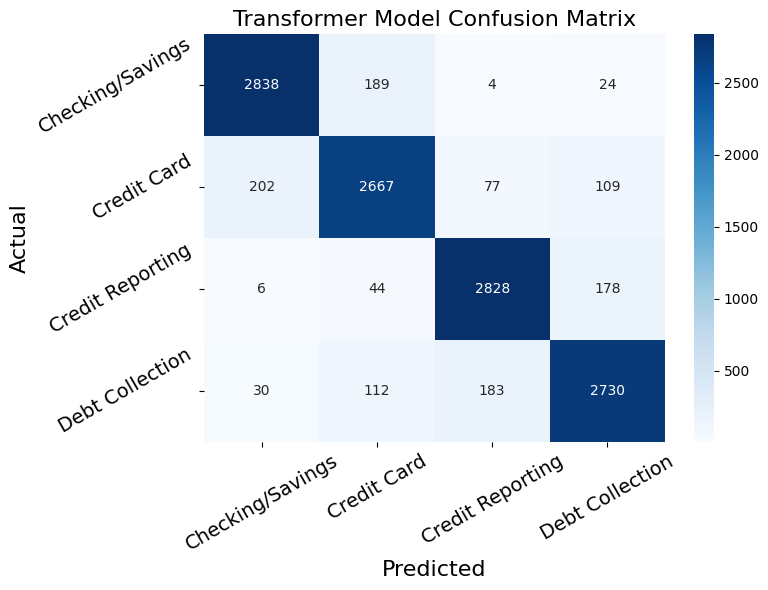

In [ ]:
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_bert,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_list,
    yticklabels=label_list
)

plt.xlabel("Predicted", fontsize=16)
plt.ylabel("Actual", fontsize=16)
plt.title("Transformer Model Confusion Matrix", fontsize=16)
plt.xticks(rotation=30, fontsize=14)
plt.yticks(rotation=30, fontsize=14)
plt.tight_layout()
plt.show()
plt.show()

Model 4: Large Language Model

In [ ]:
#the following code was generated with AI. Purchased $10 credit of tokens with OpenAI
!pip install openai

client = OpenAI(api_key="secret key has been removed")

labels = ["Checking/Savings","Credit Card","Credit Reporting","Debt Collection"]
sample_df = df_balanced.sample(200, random_state=42).copy() #AI recommended a small sample of the total dataset to build the model on

def classify(text):
    prompt = f"""Classify the complaint into ONE category:
{labels}
Complaint: {text}
Answer with only the category."""
    r = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role":"user","content":prompt}],
        temperature=0
    )
    return r.choices[0].message.content.strip()

sample_df["llm_prediction"] = sample_df["clean_text"].apply(classify)

y_true_LLM = sample_df["product_short"]
y_pred_LLM = sample_df["llm_prediction"]

print("Accuracy:", accuracy_score(y_true_LLM, y_pred_LLM))
print(classification_report(y_true_LLM, y_pred_LLM))

Accuracy: 0.73
                  precision    recall  f1-score   support

Checking/Savings       0.97      0.64      0.78        59
     Credit Card       0.88      0.81      0.84        43
Credit Reporting       0.55      1.00      0.71        45
 Debt Collection       0.72      0.53      0.61        53

        accuracy                           0.73       200
       macro avg       0.78      0.75      0.73       200
    weighted avg       0.79      0.73      0.73       200



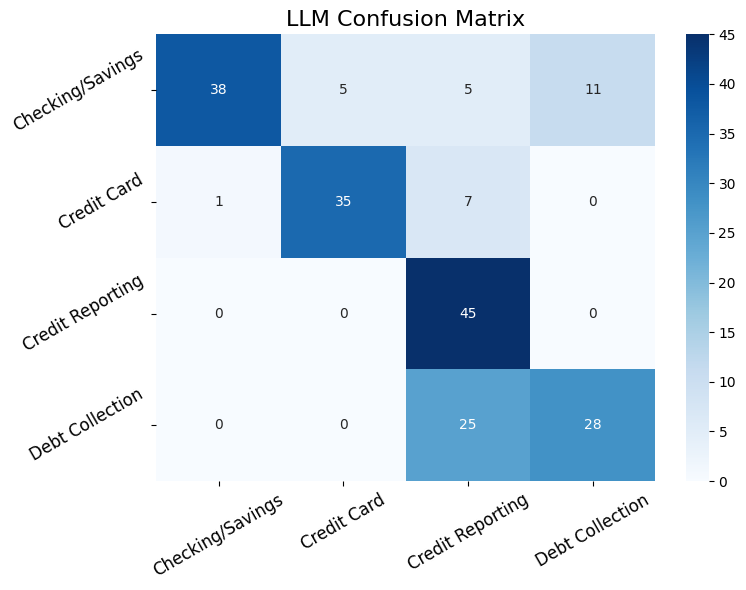

In [ ]:
cm = confusion_matrix(y_true_LLM, y_pred_LLM, labels=labels)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xticks(rotation=30, fontsize=12)
plt.yticks(rotation=30, fontsize=12)
plt.title("LLM Confusion Matrix", fontsize=16)
plt.tight_layout()
plt.show()

***Section 4.0***

Metrics

Comparsion Table for all Models

In [ ]:
results = []

baseline_acc = accuracy_score(y_true_BL, y_pred_BL)
baseline_f1 = f1_score(y_true_BL, y_pred_BL, average="macro")

results.append({
    "Model": "Rule-Based Baseline",
    "Accuracy": baseline_acc,
    "Macro F1": baseline_f1
})

svm_acc = accuracy_score(y_test_svm, y_pred_svm)
svm_f1 = f1_score(y_test_svm, y_pred_svm, average="macro")

results.append({
    "Model": "TF-IDF + Linear SVM",
    "Accuracy": svm_acc,
    "Macro F1": svm_f1
})

bert_acc = accuracy_score(y_true_bert, y_pred_bert)
bert_f1 = f1_score(y_true_bert, y_pred_bert, average="macro")

results.append({
    "Model": "Transformer (BERT)",
    "Accuracy": bert_acc,
    "Macro F1": bert_f1
})

llm_acc = accuracy_score(y_true_LLM, y_pred_LLM)
llm_f1 = f1_score(y_true_LLM, y_pred_LLM, average="macro")

results.append({
    "Model": "LLM",
    "Accuracy": llm_acc,
    "Macro F1": llm_f1
})
results_df = pd.DataFrame(results)
results_df["Accuracy"] = results_df["Accuracy"].round(3)
results_df["Macro F1"] = results_df["Macro F1"].round(3)

results_df

,Model,Accuracy,Macro F1
0,Rule-Based Baseline,0.639,0.625
1,TF-IDF + Linear SVM,0.893,0.892
2,Transformer (BERT),0.905,0.905
3,LLM,0.730,0.734


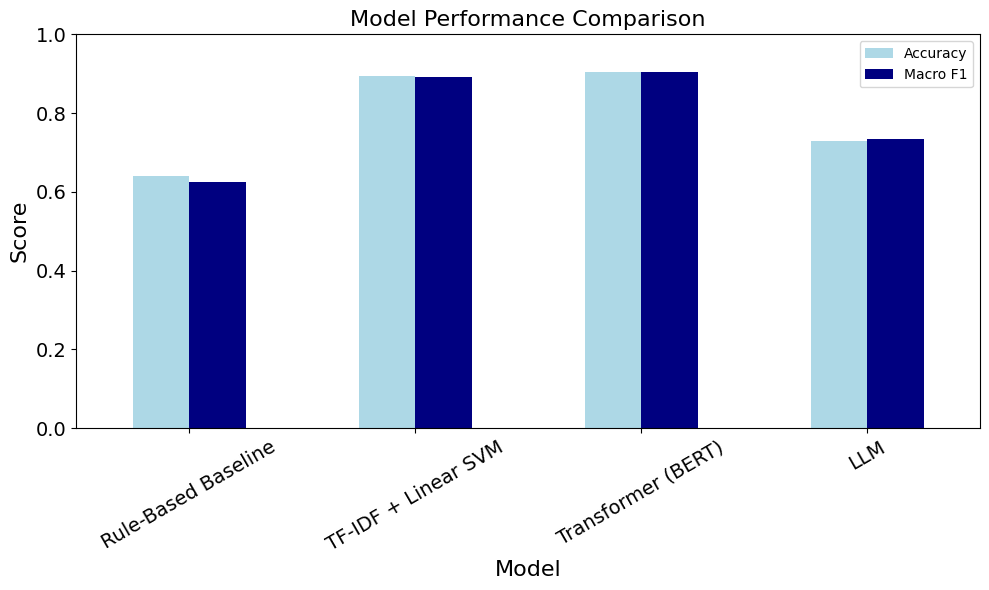

In [ ]:
results_df.set_index("Model")[["Accuracy","Macro F1"]].plot(
    kind="bar",
    figsize=(10,6),
    color=["lightblue","navy"]
)

plt.title("Model Performance Comparison", fontsize=16)
plt.xlabel("Model", fontsize=16)
plt.ylabel("Score", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(rotation=30, fontsize=14)
plt.ylim(0,1)
plt.tight_layout()
plt.show()